# 1. Dataset Description
 
**Source:** PJM Interconnection Hourly Load Data  
**Time Span:** Hourly observations from 1998 onward  
**Data Type:** Univariate, equally spaced, hourly time series  
**Variable:** Electricity demand (in Megawatts, MW)

### Selected Region for Analysis
To ensure clarity and depth in our analysis, we will focus on a single region rather than the entire dataset.

* **Selected Region:** AEP (American Electric Power)

**Justification for Selection:**
* **Data Availability:** Contains a long, continuous time span.
* **Signal Quality:** Exhibits clear seasonality and trend components.
* **Relevance:** It is a standard benchmark commonly used in academic time series research.

# 2. Load Libraries and Dataset

# 1. Data Manager & Exploration
**Objective:** Prepare a clean, reliable dataset for time series modeling.

**Dataset Selection:** We have selected the **PJME (PJM East)** region for this analysis. 
* **Reasoning:** PJME offers the longest historical data range (starting from 2002), providing over 2.5 years more data than other regions like AEP. This extended history allows the model to learn from a wider variety of seasonal patterns and economic conditions.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose


In [3]:
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (15, 6)

## 2. Data Acquisition
To ensure reproducibility and ease of access for all team members, the dataset is ingested directly from a shared Google Drive repository.

**Process:**
1.  **Ingestion:** The raw CSV is streamed via URL, parsed, and indexed by `Datetime`.
2.  **Filtering:** We isolate the **PJME** column.
3.  **Trimming:** We remove leading `NaN` values (data prior to 2002) to establish a valid starting point for the time series.

In [4]:
FILE_ID = "1J0VT7iFcrmimk1owa1tUUYuo3NTDiIT_"
#url = f"https://drive.google.com/uc?id={FILE_ID}"


def load_pjme_from_gdrive(file_id):
    url = f"https://drive.google.com/uc?id={file_id}"
    df = pd.read_csv(url)
    df["Datetime"] = pd.to_datetime(df["Datetime"])
    return df.set_index("Datetime").sort_index()

df = load_pjme_from_gdrive(FILE_ID)


In [5]:
# 2. Select Target Region (PJME) & Initial Filtering
# We focus strictly on PJM East. We also trim data before the first valid index.
pjme = df[['PJME']].copy()
first_valid = pjme.first_valid_index()
last_valid = pjme.last_valid_index()
pjme = pjme.loc[first_valid:last_valid]

print(f"\nTarget Region: PJME")
print(f"Time Range: {pjme.index.min()} to {pjme.index.max()}")
print(f"Total Hours: {len(pjme)}")


Target Region: PJME
Time Range: 2002-01-01 01:00:00 to 2018-08-03 00:00:00
Total Hours: 145366


## 3. Data Cleaning

### Handling Duplicates
We identified a small number of duplicate timestamp indices. These usually occur during the Daylight Saving Time (DST) transition in autumn, where the clock "falls back," causing an hour to repeat. We resolved this by averaging the energy consumption values for the conflicting timestamps.

### Imputation
Upon reindexing the dataframe to a strict hourly frequency, we discovered approximately **30 missing hours** (gaps in the data).
* **Method:** Linear Interpolation.
* **Justification:** Electricity demand is a continuous physical phenomenon. For short gaps (1-2 hours), linear interpolation provides a safe and realistic estimate without introducing artificial variance or bias that might come from more complex imputation methods.

In [6]:
# 1. Handle Duplicates
duplicate_count = pjme.index.duplicated().sum()
print(f"Duplicate indices found: {duplicate_count}")

# Resolve duplicates by taking the mean of the values
pjme = pjme.groupby(pjme.index).mean()

# 2. Handle Missing Values (Imputation)
full_idx = pd.date_range(start=pjme.index.min(), end=pjme.index.max(), freq='H')
pjme = pjme.reindex(full_idx)

# Count missing values
missing_count = pjme['PJME'].isna().sum()
print(f"Missing hours to be imputed: {missing_count}")

# Impute using Linear Interpolation
# This fills the NaN gaps by drawing a straight line between the last valid and next valid points.
pjme['PJME'] = pjme['PJME'].interpolate(method='linear')

print("Cleaning complete. Missing values remaining:", pjme['PJME'].isna().sum())

Duplicate indices found: 4
Missing hours to be imputed: 30
Cleaning complete. Missing values remaining: 0


/var/folders/zc/sdlj288n03ld3s3l_mzb9f0r0000gn/T/ipykernel_44580/2736771120.py:9: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  full_idx = pd.date_range(start=pjme.index.min(), end=pjme.index.max(), freq='H')


## 4. Resampling
We aggregate the dataset from **Hourly** to **Daily** frequency by calculating the mean consumption for each day.

**Reasoning:**
1.  **Noise Reduction:** Hourly fluctuations are often driven by immediate human activity (waking up, cooking, etc.). Daily aggregation smooths out this high-frequency noise, making long-term trends and seasonalities (annual cycles) much clearer.
2.  **Efficiency:** This reduces the dataset size by a factor of 24, significantly speeding up the training time for forecasting models without losing the core signal needed for predicting daily energy demand.

In [ ]:
# Resample to Daily frequency (Mean aggregation)
# 'D' stands for Calendar Day frequency
pjme_daily = pjme.resample('D').mean()
 
# Display the first few rows of the clean daily data
print("Daily Data Head:")
print(pjme_daily.head())

print(f"\nNew shape (Daily): {pjme_daily.shape}")

Daily Data Head:
                    PJME
2002-01-01  31080.739130
2002-01-02  34261.541667
2002-01-03  34511.875000
2002-01-04  33715.458333
2002-01-05  30405.125000

New shape (Daily): (6059, 1)


# Step 5: Exploratory Data Analysis (EDA) & Decomposition

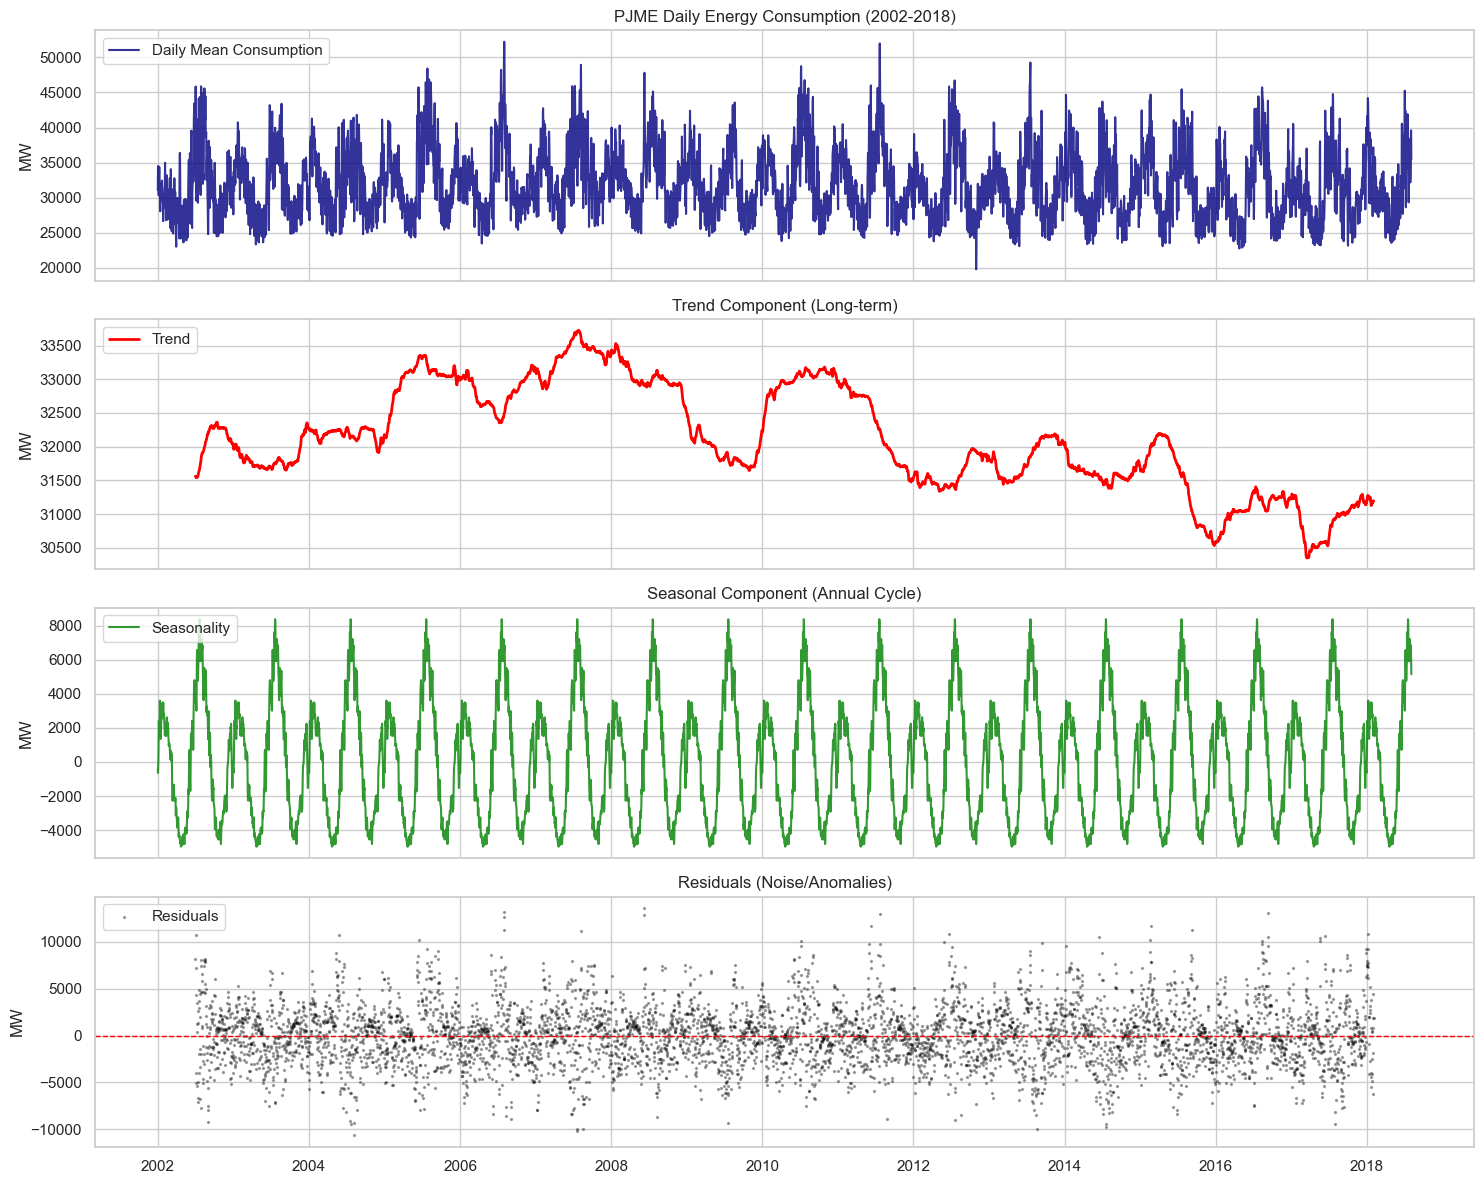

In [8]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set(style="whitegrid")

# 1. Decompose the time series
# We use period=365 because we have daily data and expect an annual cycle.
decomposition = seasonal_decompose(pjme_daily['PJME'], model='additive', period=365)

# 2. Plotting
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(15, 12), sharex=True)

# Original Data
ax1.plot(pjme_daily.index, pjme_daily['PJME'], label='Daily Mean Consumption', color='navy', alpha=0.8)
ax1.set_title('PJME Daily Energy Consumption (2002-2018)')
ax1.set_ylabel('MW')
ax1.legend(loc='upper left')

# Trend
ax2.plot(decomposition.trend, label='Trend', color='red', linewidth=2)
ax2.set_title('Trend Component (Long-term)')
ax2.set_ylabel('MW')
ax2.legend(loc='upper left')

# Seasonality
ax3.plot(decomposition.seasonal, label='Seasonality', color='green', alpha=0.8)
ax3.set_title('Seasonal Component (Annual Cycle)')
ax3.set_ylabel('MW')
ax3.legend(loc='upper left')

# Residuals
ax4.scatter(pjme_daily.index, decomposition.resid, label='Residuals', color='black', alpha=0.3, s=2)
ax4.axhline(0, color='red', linestyle='--', linewidth=1)
ax4.set_title('Residuals (Noise/Anomalies)')
ax4.set_ylabel('MW')
ax4.legend(loc='upper left')

plt.tight_layout()
plt.show()

## 5. Exploratory Data Analysis (EDA) & Decomposition
We applied `seasonal_decompose` (additive model) to break the time series into three distinct components:

1.  **Trend:**
    * We observe a gradual increase in energy consumption peaking around 2008.
    * Post-2008, the trend stabilizes or slightly declines, possibly reflecting the economic recession or improvements in energy efficiency/technology.

2.  **Seasonality:**
    * The data exhibits a very strong, consistent **Annual Seasonality**.
    * **Dual Peaks:** We see high demand in **Summer** (likely due to air conditioning) and **Winter** (heating), with lower demand in the transitional seasons (Spring/Autumn).

3.  **Residuals:**
    * The residuals represent the "noise" or unexplained variance after removing trend and seasonality.
    * Significant spikes in the residuals often correspond to extreme weather events (heatwaves or polar vortexes) that deviate from the average seasonal expectation.

## 6. Output Generation
We export the processed data in two resolutions to accommodate different modeling strategies:

1.  **`pjme_hourly_cleaned.csv`**:
    * **Description:** The fully cleaned hourly time series (imputed & deduplicated).
    * **Use Case:** Deep Learning models (LSTM/GRU) and analysis of intra-day patterns (peak load profiling).

2.  **`pjme_daily_cleaned.csv`**:
    * **Description:** Daily average consumption.
    * **Use Case:** Statistical forecasting (ARIMA, Prophet) and long-term trend visualization.

The Data Management phase is now complete.

In [11]:
# 1. Save the Cleaned Hourly Data
# This dataset retains the original granularity but with all gaps filled and duplicates removed.
hourly_filename = 'pjme_hourly_cleaned.csv'
pjme.to_csv(hourly_filename)

# 2. Save the Aggregated Daily Data
# This dataset is smaller and smoother.
daily_filename = 'pjme_daily_cleaned.csv'
pjme_daily.to_csv(daily_filename)

print("Export Complete:")
print(f"1. Hourly Data Saved: {hourly_filename} (Shape: {pjme.shape})")
print(f"2. Daily Data Saved:  {daily_filename} (Shape: {pjme_daily.shape})")
print("\nReady for the Modeling Team.")

Export Complete:
1. Hourly Data Saved: pjme_hourly_cleaned.csv (Shape: (145392, 1))
2. Daily Data Saved:  pjme_daily_cleaned.csv (Shape: (6059, 1))

Ready for the Modeling Team.
